In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_data(path = "tags-20210226.csv"):
    return pd.read_csv(path)


In [3]:
# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

## Tags EDA

In [4]:

df_tags = load_data()

In [5]:
df_tags.head(5)

,id,type,name,canonical,cached_count,merger_id
0,1,Media,TV Shows,True,910,NaN
1,2,Media,Movies,True,1164,NaN
2,3,Media,Books & Literature,True,134,NaN
3,4,Media,Cartoons & Comics & Graphic Novels,True,166,NaN
4,5,Media,Anime & Manga,True,501,NaN


In [6]:
print(f"Shape: {df_tags.shape}")
print(f"\nColumn types:\n{df_tags.dtypes}")

Shape: (14467138, 6)

Column types:
id                int64
type             object
name             object
canonical          bool
cached_count      int64
merger_id       float64
dtype: object


In [7]:
df_tags.describe(include='all').round(2)

,id,type,name,canonical,cached_count,merger_id
count,14467138.00,14467138,14467135,14467138,14467138.00,3466917.00
unique,NaN,9,1621973,2,NaN,NaN
top,NaN,Freeform,Redacted,False,NaN,NaN
freq,NaN,9244331,12845163,13291100,NaN,NaN
mean,27166031.48,NaN,NaN,NaN,10.15,14412910.06
std,16681853.91,NaN,NaN,NaN,2093.44,16735997.56
min,1.00,NaN,NaN,NaN,0.00,25.00
25%,12466060.00,NaN,NaN,NaN,1.00,227826.00
50%,27524572.00,NaN,NaN,NaN,1.00,6541412.00
75%,41748064.75,NaN,NaN,NaN,1.00,26810423.00


### Cleaning tag data

In [8]:
df_tags.isnull().sum()

id                     0
type                   0
name                   3
canonical              0
cached_count           0
merger_id       11000221
dtype: int64

In [9]:
print(f"Percentage of missing values in merger_id  column {df_tags["merger_id"].isna().mean() * 100 :.2f} %")

Percentage of missing values in merger_id  column 76.04 %


I don't need merger id and it is mostly missing values (76%) I will drop the three missing tags and merger id column 

In [10]:
df_tags_clean= df_tags.copy()

In [11]:
df_tags_clean = df_tags_clean.drop(columns=['merger_id'])

In [12]:
df_tags_clean = df_tags_clean.dropna(subset=['name'])

### Plot  tags

in ao3 there are different types of tags 

In [13]:
df_tags_clean["type"].unique()

array(['Media', 'Rating', 'ArchiveWarning', 'Category', 'Character',
       'Fandom', 'Relationship', 'Freeform', 'UnsortedTag'], dtype=object)

In [14]:
media = df_tags_clean[df_tags_clean["type"] == "Media"]

In [21]:
def plot_type(type, title="type", figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.plot(type['name'], type['cached_count'], marker='o', linestyle='-', color='blue')

    # Labels and title
    plt.xlabel('Name of Tag')
    plt.ylabel('Count')
    plt.title(f"Count of Fan Works Based on {title}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()


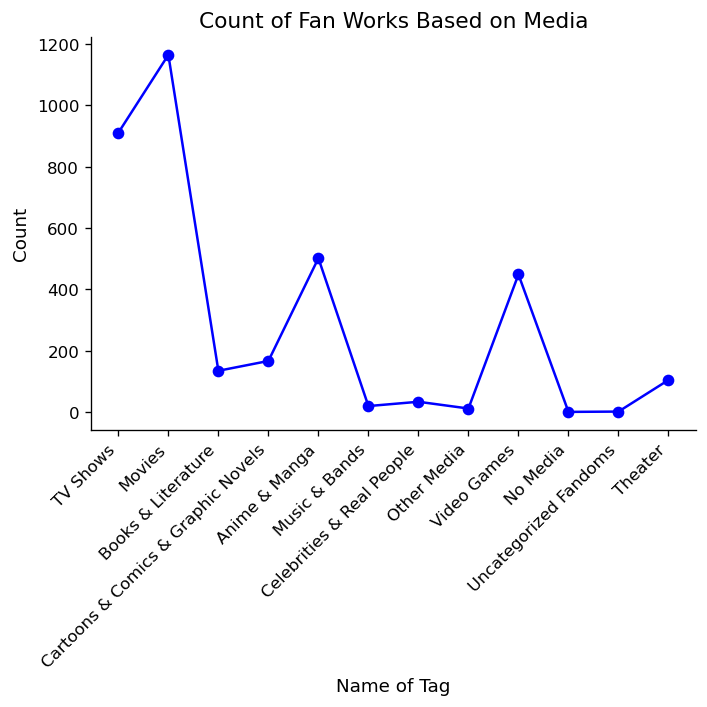

In [16]:
plot_type(media, "Media")

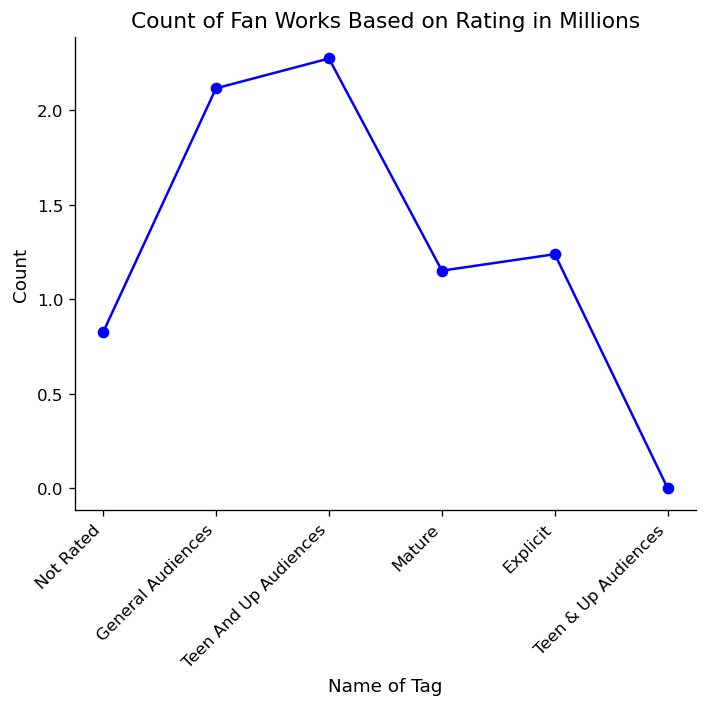

In [17]:
rate = df_tags_clean[df_tags_clean["type"] == "Rating"].copy()
rate["cached_count"] = rate["cached_count"] / 1000000
plot_type(rate, "Rating in Millions")

In [ ]:
fandom = df_tags_clean[df_tags_clean["type"] == "Fandom"].copy()
# rate["cached_count"] = rate["cached_count"] / 1000000

fandom = fandom.sort_values(by='cached_count', ascending=False)
fandom_20 = fandom.head(10)

In [29]:
fandom.head(10)

,id,type,name,canonical,cached_count
94292,136512,Fandom,Harry Potter - J. K. Rowling,True,361919
25,27,Fandom,Supernatural,True,310300
230408,414093,Fandom,Marvel Cinematic Universe,True,240536
1553725,3828398,Fandom,僕のヒーローアカデミア | Boku no Hero Academia | My Hero ...,True,204096
680695,1002903,Fandom,방탄소년단 | Bangtan Boys | BTS,True,203097
168289,258526,Fandom,Teen Wolf (TV),True,172802
679946,1001939,Fandom,The Avengers (Marvel Movies),True,157813
92059,133185,Fandom,Sherlock (TV),True,151925
5974,7266,Fandom,Marvel,True,147757
494603,758208,Fandom,Haikyuu!!,True,130918


C:\Users\kareman\AppData\Local\Temp\ipykernel_27916\1445113762.py:10: UserWarning: Glyph 20693 (\N{CJK UNIFIED IDEOGRAPH-50D5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kareman\AppData\Local\Temp\ipykernel_27916\1445113762.py:10: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kareman\AppData\Local\Temp\ipykernel_27916\1445113762.py:10: UserWarning: Glyph 12498 (\N{KATAKANA LETTER HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kareman\AppData\Local\Temp\ipykernel_27916\1445113762.py:10: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kareman\AppData\Local\Temp\ipykernel_27916\1445113762.py:10: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kareman\AppData\Local\Temp\ipykernel_27916\1445113762.py:10: UserWarning: Glyph 12450 (\

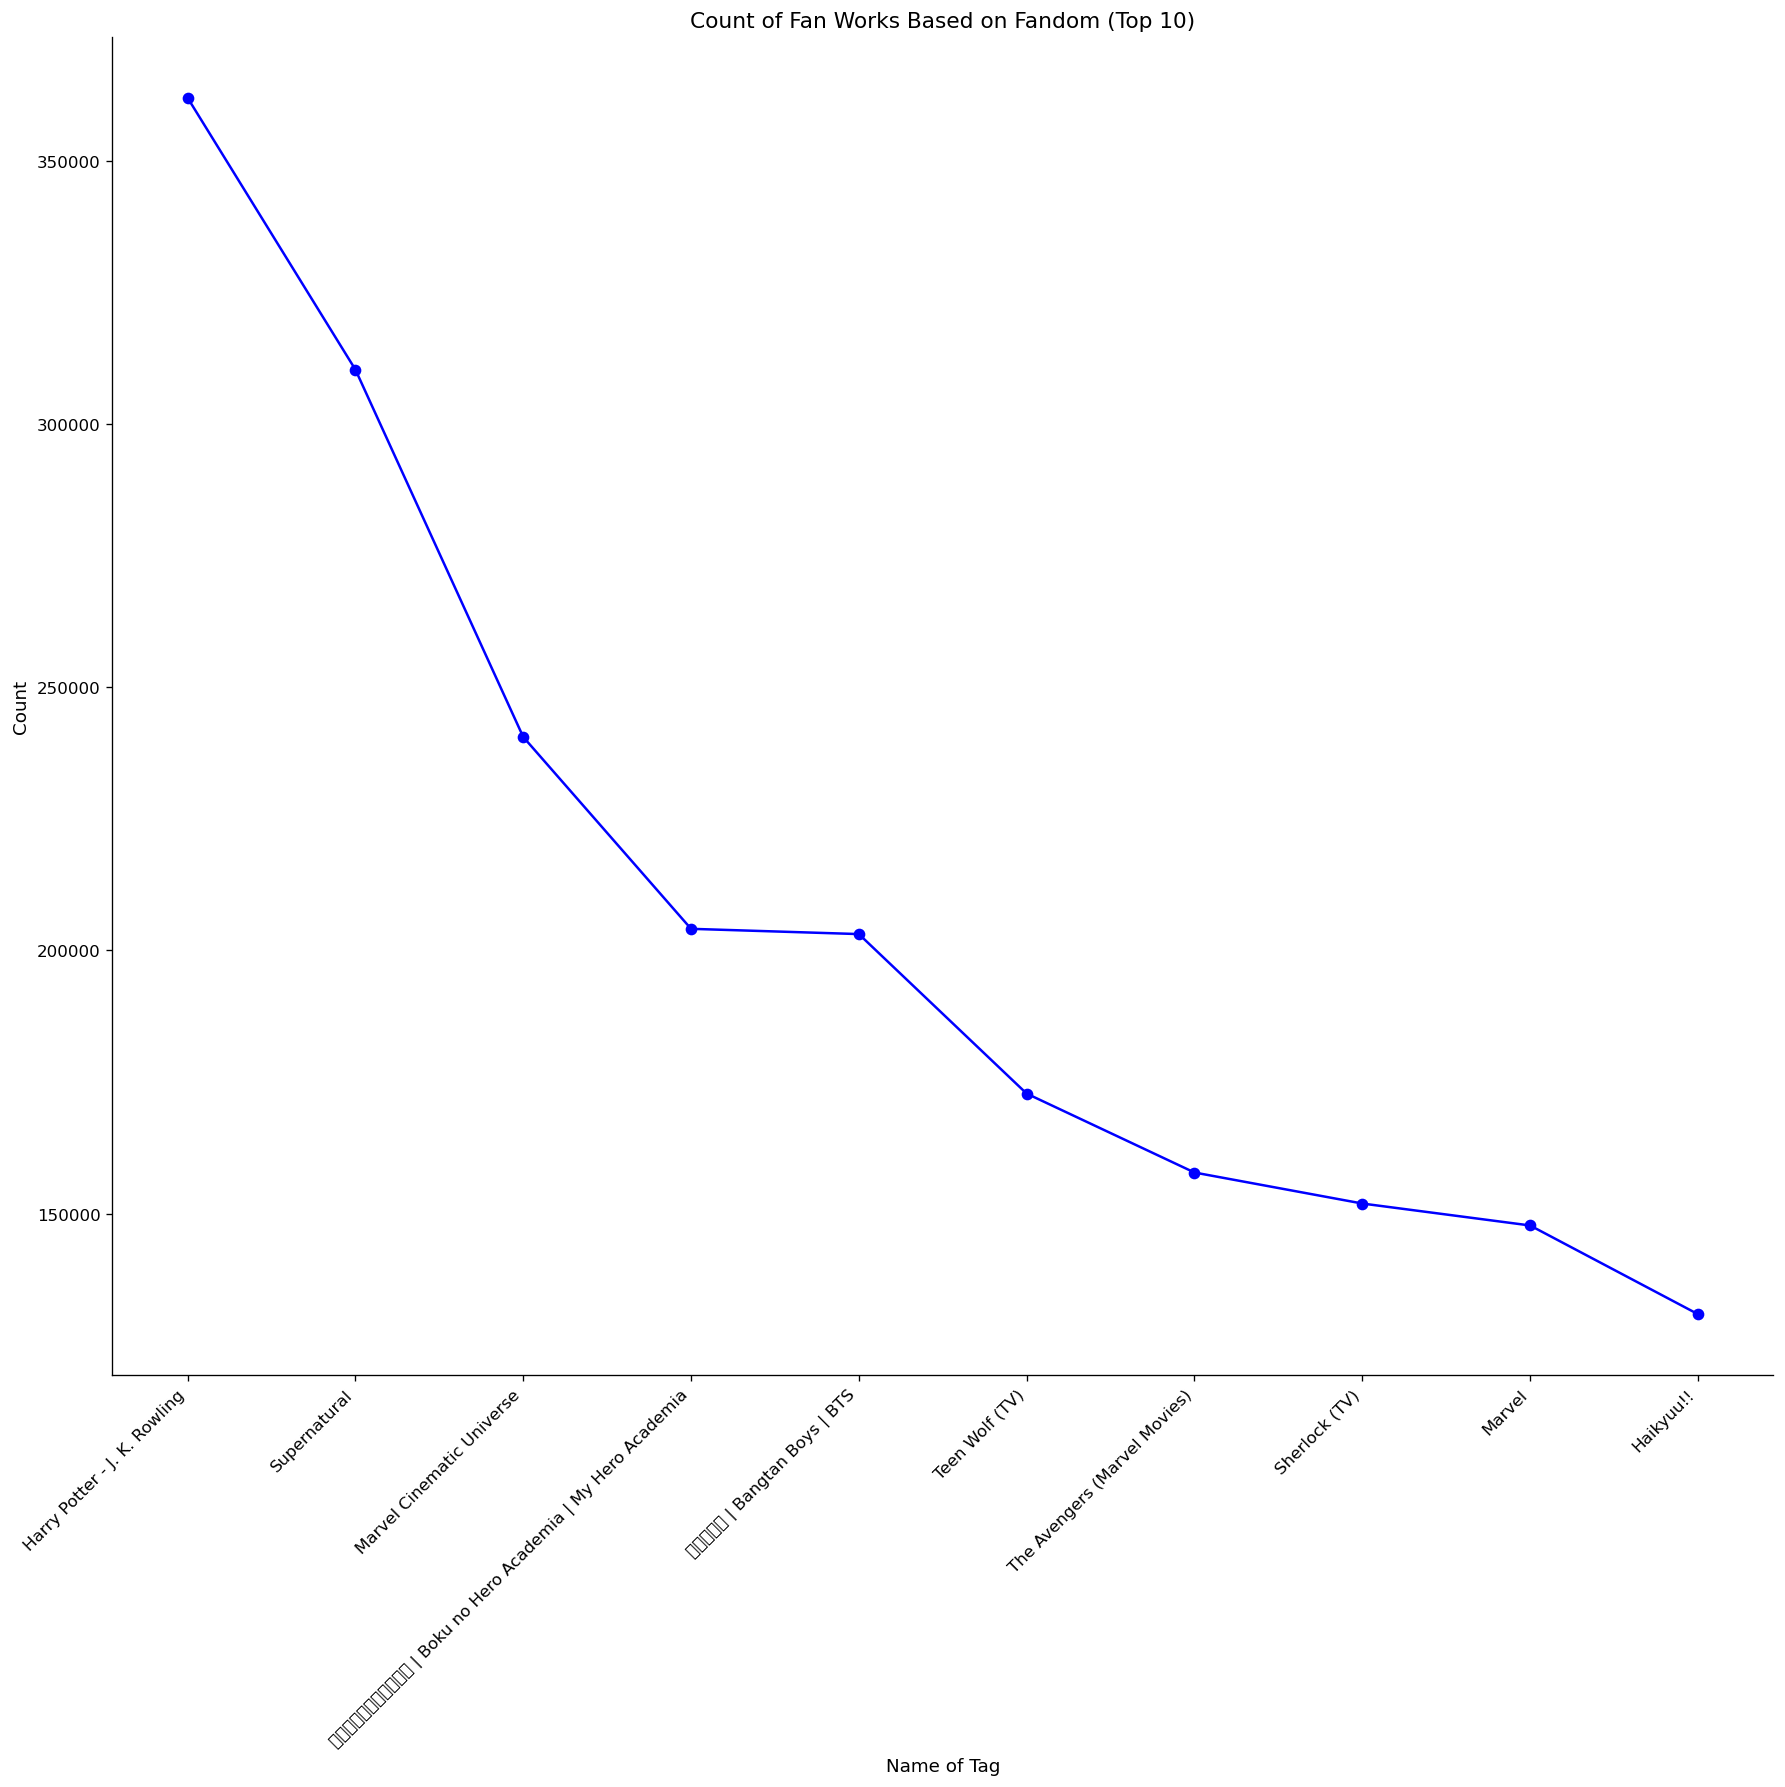

In [34]:
plot_type(fandom_20, "Fandom (Top 10)", figsize=(15,15))

based on the information so far most works are rates teen and up or general audience and most works are in movies or tv show category

## Works data with no text

In [31]:
df_works = load_data(path = "random works - Oct 2025.csv")

In [32]:
df_works.head(10)

,Unnamed: 0,URL,Title,Authors,Rating Tags,Warning Tags,Category Tags,Fandom Tags,Relationship Tags,Character Tags,...,Chapters,Intended_chapters,Words,Comments,Kudos,Bookmarks,Hits,Summary Paragraphs,Summary Words,Summary Characters
0,0,https://archiveofourown.org/works/33980032,Warm Hugs from Close Friends,"['AbsentReverie', 'NightTanzy']",[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' F/M'],"['Persona Series', 'Persona 3', 'Persona 4']","['Arisato Minako/Narukami Yu', 'Female Persona...","['Arisato Minako', 'Arisato Minato', 'Narukami...",...,1,1,2648,3,29,1,671,4,179,1033
1,1,https://archiveofourown.org/works/33979747,Tornado Warning,['coughsyrup'],[' Explicit'],"[' Rape/Non-Con', 'Underage Sex']",[' M/M'],['Persona 4'],['Adachi Tohru/Tatsumi Kanji'],"['Adachi Tohru', 'Tatsumi Kanji']",...,1,1,2786,5,82,6,1508,1,8,50
2,2,https://archiveofourown.org/works/33469771,Baton Pass,['CatMcHall'],[' Teen And Up Audiences'],"[' Graphic Depictions Of Violence', 'Major Cha...",[' F/M'],['Persona 5'],['Kurusu Akira/Niijima Makoto'],"['Kurusu Akira', 'Niijima Makoto', 'Takamaki A...",...,6,0,10789,22,70,18,2950,5,116,659
3,3,https://archiveofourown.org/works/33967459,"All For You, Darling",['Squidapples'],[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' M/M'],['Persona 5'],"['Akechi Goro/Persona 5 Protagonist', 'Akechi ...","['Amamiya Ren (Persona Series)', 'Akechi Goro'...",...,1,1,2669,1,63,8,1555,1,27,152
4,4,https://archiveofourown.org/works/33976522,"i glance at you, i miss you a bit",['summerscouts'],[' General Audiences'],[' No Archive Warnings Apply'],[' M/M'],['Persona 5'],"['Persona 5 Protagonist/Sakamoto Ryuji', 'Kuru...","['Sakamoto Ryuji', 'Amamiya Ren (Persona Serie...",...,1,1,730,0,50,1,579,2,27,148
5,5,https://archiveofourown.org/works/33974413,valentine,['summerscouts'],[' General Audiences'],[' No Archive Warnings Apply'],[' M/M'],['Persona 5'],"['Persona 5 Protagonist/Sakamoto Ryuji', 'Kuru...","['Amamiya Ren (Persona Series)', 'Sakamoto Ryu...",...,1,1,829,2,81,4,1059,2,26,158
6,6,https://archiveofourown.org/works/33969571,Eigengrau,['LunaChi_KuroShihone'],[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' Gen'],['Persona 5'],[],"['Persona 5 Protagonist', 'Amamiya Ren (Person...",...,1,1,7563,6,65,15,891,8,152,878
7,7,https://archiveofourown.org/works/33970207,First Time Going Further,['Hex69'],[' Explicit'],[' Underage Sex'],[' M/M'],['Persona 5'],['Kurusu Akira/Sakamoto Ryuji'],"['Kurusu Akira', 'Sakamoto Ryuji']",...,1,1,695,2,54,9,2495,1,15,92
8,8,https://archiveofourown.org/works/33969718,lingering fear,['radishphilosophy'],[' Mature'],[' No Archive Warnings Apply'],[' Gen'],['Persona 5'],"['Akechi Goro & Sakura Futaba', 'Akechi Goro &...","['Akechi Goro', 'Sakura Futaba', 'Persona 5 Pr...",...,1,1,1325,1,69,6,758,1,9,40
9,9,https://archiveofourown.org/works/33960640,The False Igor: a DaT AU One Shot,['PyromaniacalSunrise'],[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' Gen'],"['Persona 5', 'Dishonored (Video Games)', 'Per...",['Amamiya Ren/Yoshizawa Sumire | Yoshizawa Kas...,"['Amamiya Ren (Persona Series)', 'Kurusu Akira...",...,1,1,2468,5,7,3,621,1,37,188


In [33]:
print(f"Shape: {df_works.shape}")
print(f"\nColumn types:\n{df_works.dtypes}")

Shape: (92647, 26)

Column types:
Unnamed: 0             int64
URL                   object
Title                 object
Authors               object
Rating Tags           object
Warning Tags          object
Category Tags         object
Fandom Tags           object
Relationship Tags     object
Character Tags        object
Freeform Tags         object
Language Tags         object
Published              int64
Updated               object
Pos_in_series          int64
Completion              bool
Chapters               int64
Intended_chapters      int64
Words                  int64
Comments               int64
Kudos                  int64
Bookmarks              int64
Hits                   int64
Summary Paragraphs     int64
Summary Words          int64
Summary Characters     int64
dtype: object


In [35]:
df_works.describe(include='all').round(2)

,Unnamed: 0,URL,Title,Authors,Rating Tags,Warning Tags,Category Tags,Fandom Tags,Relationship Tags,Character Tags,...,Chapters,Intended_chapters,Words,Comments,Kudos,Bookmarks,Hits,Summary Paragraphs,Summary Words,Summary Characters
count,92647.00,92647,92647,92647,92647,92647,92647,92647,92647,92647,...,92647.00,92647.00,92647.00,92647.00,92647.00,92647.00,92647.00,92647.00,92647.00,92647.00
unique,NaN,91482,85266,62575,5,127,246,22072,48090,68228,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,https://archiveofourown.org/works/48496537,Jily,['orphan_account'],[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' M/M'],['Harry Potter - J. K. Rowling'],[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,3,60,3469,25993,44978,33320,4110,11846,4485,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,484.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.66,184.95,10394.32,24.01,155.15,22.74,3053.37,1.81,42.95,250.18
std,301.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.21,55120.33,33187.03,160.70,510.96,113.80,16623.06,1.52,40.42,229.51
min,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,221.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00,1.00,1106.00,1.00,13.00,1.00,247.50,1.00,14.00,86.00
50%,468.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.00,1.00,2582.00,4.00,44.00,4.00,756.00,1.00,30.00,177.00
75%,738.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.00,1.00,6995.50,13.00,128.00,14.00,2201.00,2.00,60.00,346.00


Cleaning data

In [36]:
df_works.isnull().sum()

Unnamed: 0            0
URL                   0
Title                 0
Authors               0
Rating Tags           0
Warning Tags          0
Category Tags         0
Fandom Tags           0
Relationship Tags     0
Character Tags        0
Freeform Tags         0
Language Tags         0
Published             0
Updated               0
Pos_in_series         0
Completion            0
Chapters              0
Intended_chapters     0
Words                 0
Comments              0
Kudos                 0
Bookmarks             0
Hits                  0
Summary Paragraphs    0
Summary Words         0
Summary Characters    0
dtype: int64

### Features

In [37]:
features = df_works.copy()

In [58]:
features["Words_millions"] = features["Words"] / 1000000
features["Hits_millions"] = features["Hits"] / 1000000

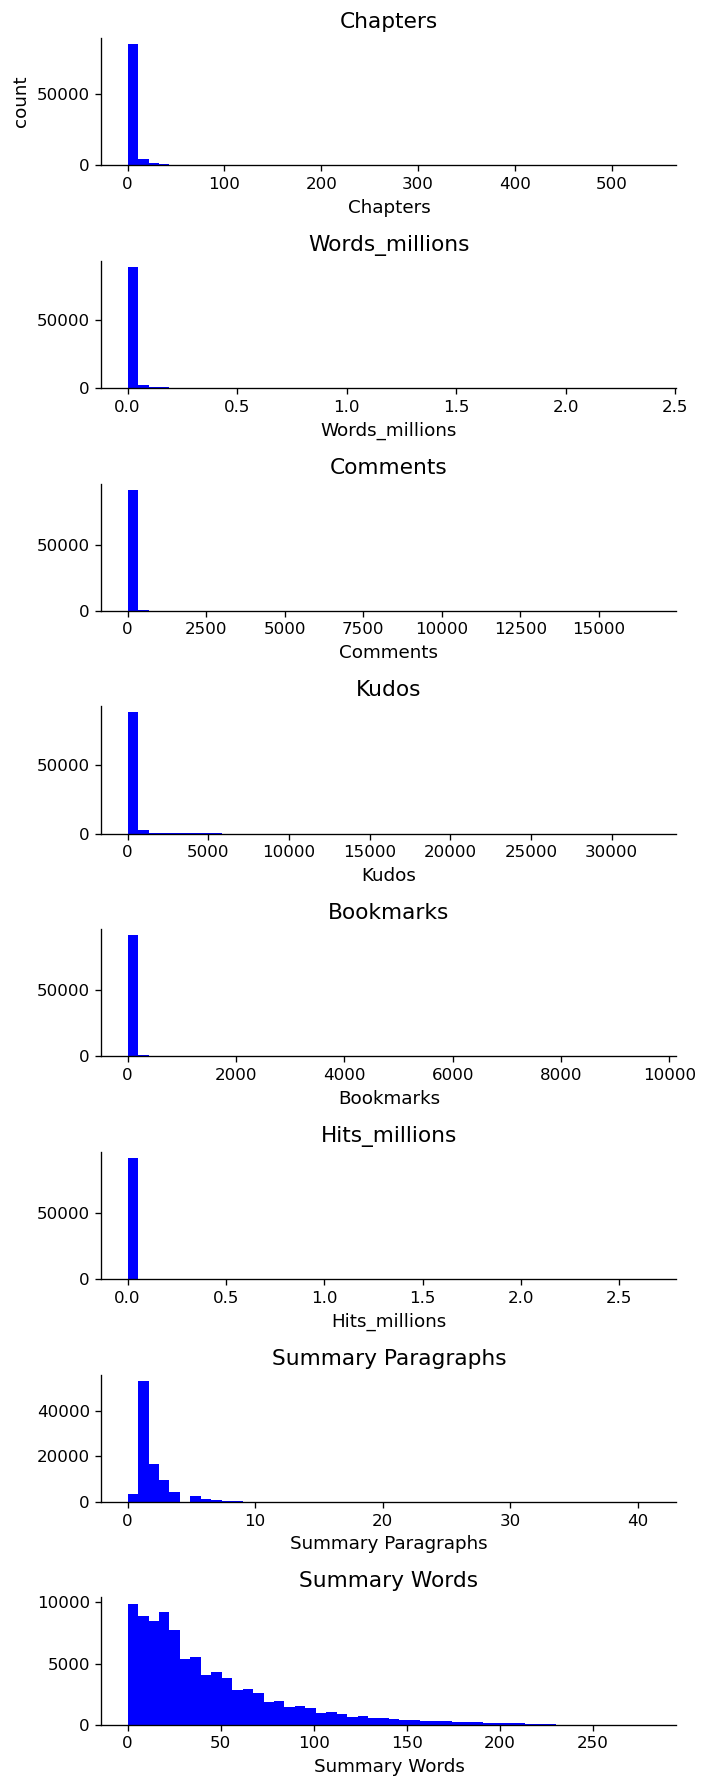

In [61]:
num_features = ['Chapters',
       'Words_millions', 'Comments', 'Kudos', 'Bookmarks',
       'Hits_millions', 'Summary Paragraphs','Summary Words']
n = len(num_features)
fig, axes =plt.subplots(n, 1,  figsize= (6,15))
# fig.subtitle("Distribution of the num features", fontsize=15, y=1.01)

for j, col in enumerate(num_features):
    
    axes[j].hist(features[col], bins=50, color="blue", lw=0.4)
    axes[j].set_xlabel(col)
    axes[j].set_ylabel("count" if j==0 else "")
    axes[j].set_title(col)
    plt.tight_layout()
    

the distribution of num features is not normal however I am not going to use them directly

In [62]:
import ast

In [43]:
features['kudos/hits'] = (features["Kudos"] / features["Hits"]).replace([np.inf, -np.inf], 0)

In [44]:
features['comments/hits'] = (features["Comments"] / features["Hits"]).replace([np.inf, -np.inf], 0)

In [45]:
features['bookmarks/hits'] = (features["Bookmarks"] / features["Hits"]).replace([np.inf, -np.inf], 0)

In [63]:
features["Fandom Tags"] = features["Fandom Tags"].apply(ast.literal_eval)

In [ ]:
#[Claude] BEGIN  i have a column with a list of tags and a column in a different dataframe with how many times a tag is used we will call that size \
# how can i create a new column in df1 with the correct size depending on the list of tags

size_map =  dict(zip(fandom["name"], fandom["cached_count"]))
features["fandom_size"] = features["Fandom Tags"].apply(lambda tag_list: max((size_map.get(tag, 0) for tag in tag_list), default=0))

#END

fandom size here is based on the tag dataset cause this dataset is from the website with the true size of each fandom not just from the count of the tag in this sample 

a work can have multiple fandom tags I decided to take the max size for example if a work is in jjk_manga (size= 50) and jjk_anime (size = 100) the result size will be 100 cause the sum doesn't make sense as a the 50 work in the jjk_manga are probably within the 100 work in jjk_anime meaning there are 50 work that is tagged jjk_manga and jjk_anime while there are 50 work tagged only jjk_anime of course that is not always the case but within fandom spaces that is the assumption. 

In [66]:
features.head(5)

,Unnamed: 0,URL,Title,Authors,Rating Tags,Warning Tags,Category Tags,Fandom Tags,Relationship Tags,Character Tags,...,Hits,Summary Paragraphs,Summary Words,Summary Characters,kudos/hits,comments/hits,bookmarks/hits,Words_millions,Hits_millions,fandom_size
0,0,https://archiveofourown.org/works/33980032,Warm Hugs from Close Friends,"['AbsentReverie', 'NightTanzy']",[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' F/M'],"[Persona Series, Persona 3, Persona 4]","['Arisato Minako/Narukami Yu', 'Female Persona...","['Arisato Minako', 'Arisato Minato', 'Narukami...",...,671,4,179,1033,0.043219,0.004471,0.001490,0.002648,0.000671,7652
1,1,https://archiveofourown.org/works/33979747,Tornado Warning,['coughsyrup'],[' Explicit'],"[' Rape/Non-Con', 'Underage Sex']",[' M/M'],[Persona 4],['Adachi Tohru/Tatsumi Kanji'],"['Adachi Tohru', 'Tatsumi Kanji']",...,1508,1,8,50,0.054377,0.003316,0.003979,0.002786,0.001508,7337
2,2,https://archiveofourown.org/works/33469771,Baton Pass,['CatMcHall'],[' Teen And Up Audiences'],"[' Graphic Depictions Of Violence', 'Major Cha...",[' F/M'],[Persona 5],['Kurusu Akira/Niijima Makoto'],"['Kurusu Akira', 'Niijima Makoto', 'Takamaki A...",...,2950,5,116,659,0.023729,0.007458,0.006102,0.010789,0.002950,21922
3,3,https://archiveofourown.org/works/33967459,"All For You, Darling",['Squidapples'],[' Teen And Up Audiences'],[' No Archive Warnings Apply'],[' M/M'],[Persona 5],"['Akechi Goro/Persona 5 Protagonist', 'Akechi ...","['Amamiya Ren (Persona Series)', 'Akechi Goro'...",...,1555,1,27,152,0.040514,0.000643,0.005145,0.002669,0.001555,21922
4,4,https://archiveofourown.org/works/33976522,"i glance at you, i miss you a bit",['summerscouts'],[' General Audiences'],[' No Archive Warnings Apply'],[' M/M'],[Persona 5],"['Persona 5 Protagonist/Sakamoto Ryuji', 'Kuru...","['Sakamoto Ryuji', 'Amamiya Ren (Persona Serie...",...,579,2,27,148,0.086356,0.000000,0.001727,0.000730,0.000579,21922


we will drop works whose fandom size is less than 100 as we don't want works that are 